# Testing: Synthetic Data

The synthetic module is a work in progress. The idea is to allow synthetic meteorological 
datasets to be readily created for testing purposes. While an entire synthetic dataset 
could be created first, then fed into THUNER in the usual way (see previous tutorials/demos)
with this module we instead generate the synthetic data as we go. The approach avoids the 
need for storing large datasets.

In [45]:
"""Synthetic data demo/test."""

%load_ext autoreload
%autoreload 2
import xarray as xr
from pathlib import Path
import shutil
import numpy as np
import thuner.data as data
import thuner.default as default
import thuner.track.track as track
import thuner.option as option
import thuner.data.synthetic as synthetic

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [64]:
# Set a flag for whether or not to remove existing output directories
remove_existing_outputs = True

# Parent directory for saving outputs
base_local = Path.home() / "THUNER_output"
start = "2005-11-13T00:00:00"
end = "2005-11-13T01:00:00"

output_parent = base_local / "runs/synthetic/geographic"
if output_parent.exists() and remove_existing_outputs:
    shutil.rmtree(output_parent)
options_directory = output_parent / "options"
options_directory.mkdir(parents=True, exist_ok=True)

# Create a grid
lat = np.arange(-14, -6 + 0.025, 0.025).tolist()
lon = np.arange(128, 136 + 0.025, 0.025).tolist()
grid_options = option.grid.GridOptions(name="geographic", latitude=lat, longitude=lon)
grid_options.to_json(options_directory / "grid.json")

# Initialize synthetic objects
starting_objects = []
for i in range(5):
    obj = synthetic.EllipsoidObject(
        time=start,
        center_latitude=np.mean(lat),
        center_longitude=lon[(i + 1) * len(lon) // 6],
        direction=-np.pi / 4 + i * np.pi / 8,
        speed=30 - 4 * i,
        horizontal_radius=7 + 4 * i,
        orientation=0.25 * np.pi + i * np.pi / 8,
    )
    starting_objects.append(obj)
# Create data options dictionary
synthetic_options = data.synthetic.SyntheticOptions(objects=starting_objects)
data_options = option.data.DataOptions(datasets=[synthetic_options])
data_options.to_json(options_directory / "data.json")

track_options = default.track.synthetic_track()
track_options.to_json(options_directory / "track.json")

# Create the display_options dictionary
visualize_options = default.visualize.synthetic_runtime(
    options_directory / "visualize.json"
)
visualize_options.to_json(options_directory / "visualize.json")

2026-06-01 22:28:21,935 - thuner.option.grid - WARNING - altitude not specified. Using default altitudes.
2026-06-01 22:28:21,936 - thuner.option.grid - WARNING - shape not specified. Will attempt to infer from input.


In [65]:
visualize_options.model_dump()

{'type': 'RuntimeOptions',
 'objects': {'convective': {'type': 'ObjectRuntimeOptions',
   'parent_local': PosixPath('/home/ewan/THUNER_output/runs/synthetic/geographic/options/visualize.json'),
   'style': 'presentation',
   'weights_filepath': None,
   'name': 'convective',
   'figures': [{'type': 'FigureOptions',
     'name': 'match',
     'function': 'thuner.visualize.runtime.visualize_tint_match',
     'style': 'presentation',
     'animate': True,
     'single_color': False,
     'template': None}],
   'animate': True,
   'single_color': False}}}

In [66]:
times = np.arange(
    np.datetime64(start),
    np.datetime64(end) + np.timedelta64(10, "m"),
    np.timedelta64(10, "m"),
)
track.track(
    times=times,
    data_options=data_options,
    grid_options=grid_options,
    track_options=track_options,
    visualize_options=visualize_options,
    output_directory=output_parent,
)

2026-06-01 22:28:23,219 - thuner.track.track - INFO - Beginning thuner tracking. Saving output to /home/ewan/THUNER_output/runs/synthetic/geographic.
2026-06-01 22:28:23,223 - thuner.track.track - INFO - Processing 2005-11-13T00:00:00.
2026-06-01 22:28:23,224 - thuner.data.synthetic.options - INFO - Updating synthetic dataset for 2005-11-13T00:00:00.
2026-06-01 22:28:24,556 - thuner.track.track - INFO - Processing hierarchy level 0.
2026-06-01 22:28:24,557 - thuner.track.track - INFO - Tracking convective.
2026-06-01 22:28:24,590 - thuner.match.match - INFO - Matching convective objects.
2026-06-01 22:28:24,590 - thuner.match.match - INFO - No current mask, or no objects in current mask.
2026-06-01 22:28:24,593 - thuner.visualize.runtime - INFO - Creating runtime visualization figures.
2026-06-01 22:28:26,428 - thuner.track.track - INFO - Processing 2005-11-13T00:10:00.
2026-06-01 22:28:26,429 - thuner.data.synthetic.options - INFO - Updating synthetic dataset for 2005-11-13T00:10:00.


![THUNER applied to synthetic data.](https://raw.githubusercontent.com/THUNER-project/THUNER/refs/heads/main/gallery/synthetic.gif)

In [67]:
data.synthetic.write_ground_truth(output_parent, data_options=data_options, times=times)

2026-06-01 22:28:57,297 - thuner.data.synthetic.truth - INFO - Wrote ground truth for synthetic.


{'synthetic':                          latitude   longitude          u          v  \
 time                id                                                
 2005-11-13 00:00:00 0  -10.000000  129.325000 -21.213203  21.213203   
                     1  -10.000000  130.675000  -9.949769  24.020868   
                     2  -10.000000  132.025000   0.000000  22.000000   
                     3  -10.000000  133.350000   6.888302  16.629832   
                     4  -10.000000  134.700000   9.899495   9.899495   
 2005-11-13 00:10:00 0   -9.884907  129.208952 -21.213203  21.213203   
                     1   -9.869692  130.620572  -9.949769  24.020868   
                     2   -9.880659  132.025000   0.000000  22.000000   
                     3   -9.909788  133.387686   6.888302  16.629832   
                     4   -9.946295  134.754166   9.899495   9.899495   
 2005-11-13 00:20:00 0   -9.769773  129.092984 -21.213203  21.213203   
                     1   -9.739374  130.566186  -9.

In [68]:
dt = xr.open_datatree(output_parent / "output.zarr", engine="zarr")

In [69]:
dt.truth

<xarray.DataTree 'truth'>
Group: /truth
└── Group: /truth/synthetic
        Dimensions:            (record: 35)
        Dimensions without coordinates: record
        Data variables:
            eccentricity       (record) float64 280B ...
            horizontal_radius  (record) float64 280B ...
            id                 (record) int64 280B ...
            intensity          (record) int64 280B ...
            latitude           (record) float64 280B ...
            longitude          (record) float64 280B ...
            orientation        (record) float64 280B ...
            time               (record) datetime64[ns] 280B ...
            u                  (record) float64 280B ...
            v                  (record) float64 280B ...

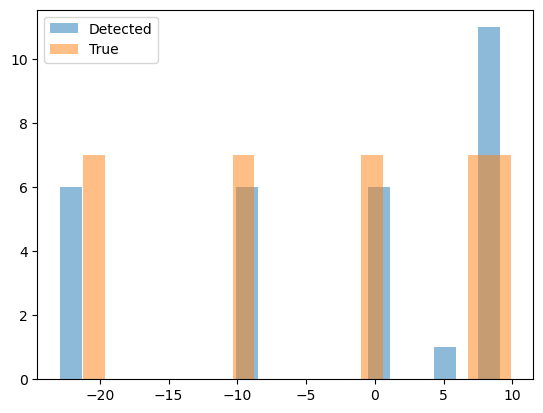

In [70]:
import matplotlib.pyplot as plt
plt.hist(dt.attributes.convective.core["u_flow"].values, label="Detected", bins=20, alpha=0.5)
plt.hist(dt.truth.synthetic["u"].values, label="True", bins=20, alpha=0.5)
plt.legend()
plt.show()

In [44]:
dt

<xarray.DataTree>
Group: /
├── Group: /masks
│   └── Group: /masks/convective
│           Dimensions:          (time: 3, latitude: 321, longitude: 322)
│           Coordinates:
│             * latitude         (latitude) float32 1kB -14.0 -13.98 -13.95 ... -6.025 -6.0
│             * longitude        (longitude) float32 1kB 128.0 128.0 128.1 ... 136.0 136.0
│             * time             (time) datetime64[ns] 24B 2005-11-13 ... 2005-11-13T00:2...
│           Data variables:
│               convective_mask  (time, latitude, longitude) uint32 1MB ...
└── Group: /truth
    └── Group: /truth/synthetic
            Dimensions:            (record: 35)
            Dimensions without coordinates: record
            Data variables:
                eccentricity       (record) float64 280B ...
                horizontal_radius  (record) float64 280B ...
                id                 (record) int64 280B ...
                intensity          (record) int64 280B ...
                latitude           (record) float64 280B ...
                longitude          (record) float64 280B ...
                orientation        (record) float64 280B ...
                time               (record) datetime64[ns] 280B ...
                u                  (record) float64 280B ...
                v                  (record) float64 280B ...

In [12]:
central_latitude = -10
central_longitude = 132

y = np.arange(-400e3, 400e3 + 2.5e3, 2.5e3).tolist()
x = np.arange(-400e3, 400e3 + 2.5e3, 2.5e3).tolist()

grid_options = option.grid.GridOptions(
    name="cartesian",
    x=x,
    y=y,
    central_latitude=central_latitude,
    central_longitude=central_longitude,
)
grid_options.to_json(options_directory / "grid.json")

2026-06-01 21:45:02,394 - thuner.option.grid - WARNING - altitude not specified. Using default altitudes.


In [13]:
output_parent = base_local / "runs/synthetic/cartesian"
if output_parent.exists() & remove_existing_outputs:
    shutil.rmtree(output_parent)
    
times = np.arange(
    np.datetime64(start),
    np.datetime64(end) + np.timedelta64(10, "m"),
    +np.timedelta64(10, "m"),
)

track.track(
    times=times,
    data_options=data_options,
    grid_options=grid_options,
    track_options=track_options,
    visualize_options=visualize_options,
    output_directory=output_parent,
)

2026-06-01 21:45:06,073 - thuner.track.track - INFO - Beginning thuner tracking. Saving output to /home/ewan/THUNER_output/runs/synthetic/cartesian.
2026-06-01 21:45:06,076 - thuner.track.track - INFO - Processing 2005-11-13T00:00:00.
2026-06-01 21:45:06,077 - thuner.data.synthetic.options - INFO - Updating synthetic dataset for 2005-11-13T00:00:00.
2026-06-01 21:45:07,246 - thuner.track.track - INFO - Processing hierarchy level 0.
2026-06-01 21:45:07,246 - thuner.track.track - INFO - Tracking convective.
2026-06-01 21:45:07,272 - thuner.match.match - INFO - Matching convective objects.
2026-06-01 21:45:07,273 - thuner.match.match - INFO - No current mask, or no objects in current mask.
2026-06-01 21:45:07,275 - thuner.visualize.runtime - INFO - Creating runtime visualization figures.
2026-06-01 21:45:08,236 - thuner.track.track - INFO - Processing 2005-11-13T00:10:00.
2026-06-01 21:45:08,237 - thuner.data.synthetic.options - INFO - Updating synthetic dataset for 2005-11-13T00:10:00.
2